<a href="https://colab.research.google.com/github/Grzegorz-GG/DissertationPW/blob/main/Experiment16.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from glob import glob
import os
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader

import wandb
import joblib
import torchvision.transforms as transforms
from torchvision.transforms import v2

from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

import timm
import matplotlib.pyplot as plt

from torch.optim.lr_scheduler import ReduceLROnPlateau
from tqdm import tqdm

In [2]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

Using device: cuda


In [3]:
gt_path = 'train_gt.csv'
wavelength_path = 'wavelengths.csv'

In [4]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
import os

output_dir = '/content/test_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/test.tar.gz -C {output_dir}

test/
test/77.npz
test/837.npz
test/189.npz
test/63.npz
test/823.npz
test/638.npz
test/610.npz
test/88.npz
test/176.npz
test/162.npz
test/604.npz
test/1145.npz
test/1151.npz
test/348.npz
test/374.npz
test/412.npz
test/406.npz
test/360.npz
test/599.npz
test/1019.npz
test/1031.npz
test/1025.npz
test/228.npz
test/200.npz
test/566.npz
test/572.npz
test/214.npz
test/943.npz
test/957.npz
test/758.npz
test/980.npz
test/994.npz
test/764.npz
test/770.npz
test/771.npz
test/765.npz
test/995.npz
test/981.npz
test/759.npz
test/956.npz
test/942.npz
test/573.npz
test/215.npz
test/201.npz
test/567.npz
test/229.npz
test/1024.npz
test/1030.npz
test/1018.npz
test/598.npz
test/407.npz
test/361.npz
test/375.npz
test/413.npz
test/349.npz
test/1150.npz
test/1144.npz
test/163.npz
test/605.npz
test/89.npz
test/611.npz
test/177.npz
test/639.npz
test/822.npz
test/62.npz
test/836.npz
test/76.npz
test/188.npz
test/60.npz
test/820.npz
test/74.npz
test/834.npz
test/48.npz
test/808.npz
test/149.npz
test/607.npz
test/

In [6]:
import os

output_dir = '/content/train_data'
if not os.path.exists(output_dir):
    os.makedirs(output_dir)

!tar -xzvf /content/drive/MyDrive/train.tar.gz -C {output_dir}

train/
train/77.npz
train/837.npz
train/189.npz
train/1409.npz
train/63.npz
train/823.npz
train/1347.npz
train/1421.npz
train/1435.npz
train/1353.npz
train/638.npz
train/610.npz
train/1384.npz
train/88.npz
train/176.npz
train/162.npz
train/1390.npz
train/604.npz
train/1179.npz
train/1623.npz
train/1145.npz
train/1151.npz
train/1637.npz
train/348.npz
train/374.npz
train/1186.npz
train/412.npz
train/406.npz
train/1192.npz
train/360.npz
train/599.npz
train/1019.npz
train/1031.npz
train/1025.npz
train/228.npz
train/200.npz
train/566.npz
train/572.npz
train/214.npz
train/943.npz
train/1569.npz
train/957.npz
train/1233.npz
train/1555.npz
train/1541.npz
train/1227.npz
train/758.npz
train/980.npz
train/994.npz
train/764.npz
train/1596.npz
train/1582.npz
train/770.npz
train/1583.npz
train/771.npz
train/765.npz
train/1597.npz
train/995.npz
train/981.npz
train/759.npz
train/1540.npz
train/1226.npz
train/1232.npz
train/1554.npz
train/956.npz
train/942.npz
train/1568.npz
train/573.npz
train/215.npz

In [7]:
gt_df = pd.read_csv(gt_path)
wavelength_df = pd.read_csv(wavelength_path)

In [92]:
def load_data(directory: str):
    data = []

    all_files = np.array(
        sorted(
            glob(os.path.join(directory, "*.npz")),
            key=lambda x: int(os.path.basename(x).replace(".npz", "")),
        )
    )

    for file_name in all_files:
        with np.load(file_name) as npz:
            raw_arr = np.ma.MaskedArray(data=npz['data'], mask=npz['mask'])
            img_tensor_raw = torch.as_tensor(raw_arr.data, dtype=torch.float)
            img_tensor_mask = ~torch.as_tensor(raw_arr.mask) # Revert mask: 0 is invalid, 1 is valid
            img_tensor_masked = torch.mul(img_tensor_raw, img_tensor_mask)
        data.append(img_tensor_masked)

    return data

In [93]:
def load_gt(file_path: str):
    """Load labels for train set from the ground truth file.
    Args:
        file_path (str): Path to the ground truth .csv file.
    Returns:
        [type]: 2D numpy array with soil properties levels
    """
    gt_file = pd.read_csv(file_path)
    labels = gt_file[["P", "K", "Mg", "pH"]].values
    return labels

In [173]:
X_train = load_data("/content/train_data/train")
y_train = load_gt("train_gt.csv")

In [289]:
# Collect all pixels for PCA
# =========================
def collect_pixels(data_list, max_pixels=10000000):
    """
    Flatten pixels from all patches for PCA, sampling to control memory usage.
    Samples pixels from each patch to ensure the total collected does not exceed max_pixels.
    """
    all_pixels = []
    # Estimate total pixels to determine sampling ratio
    total_potential_pixels = sum(arr.shape[1] * arr.shape[2] for arr in data_list)

    sampling_ratio = 1.0
    if total_potential_pixels > max_pixels:
        sampling_ratio = max_pixels / total_potential_pixels
        print(f"Sampling {sampling_ratio*100:.2f}% of pixels to stay within {max_pixels} limit.")

    for arr in data_list:
        #data = arr.filled(0) if isinstance(arr, np.ma.MaskedArray) else arr
        data = np.transpose(arr, (1, 2, 0))  # H, W, C
        pixels = data.reshape(-1, data.shape[-1]) # (H*W, C)

        if sampling_ratio < 1.0 and pixels.shape[0] > 0:
            num_pixels_to_sample = int(pixels.shape[0] * sampling_ratio)
            # Ensure we don't try to sample more pixels than available
            num_pixels_to_sample = max(1, min(num_pixels_to_sample, pixels.shape[0]))
            idx = np.random.choice(pixels.shape[0], num_pixels_to_sample, replace=False)
            all_pixels.append(pixels[idx])
        else:
            all_pixels.append(pixels)

    if not all_pixels:
        return np.empty((0, data_list[0].shape[0])) # Return empty array with correct feature dim

    X = np.vstack(all_pixels)
    return X


In [290]:
def transform_patches(data_list, scaler, pca):
    """
    Transforms a list of data patches using a fitted StandardScaler and PCA.

    Args:
        data_list (list): A list of torch.Tensor or numpy.ndarray objects,
                          each representing a hyperspectral image patch (C, H, W).
        scaler (StandardScaler): A fitted StandardScaler object.
        pca (PCA): A fitted PCA object.

    Returns:
        list: A list of transformed patches, where each patch is a torch.Tensor
              with reduced dimensions (n_components, H, W).
    """
    transformed_list = []
    for arr in data_list:
        #data = arr.filled(0) if isinstance(arr, np.ma.MaskedArray) else arr
        data = np.transpose(arr, (1, 2, 0))  # H, W, C
        H, W, C = data.shape
        pixels = data.reshape(-1, C)
        pixels_scaled = scaler.transform(pixels)
        pixels_pca = pca.transform(pixels_scaled)
        data_pca = pixels_pca.reshape(H, W, -1)

        tensor_patch = torch.from_numpy(np.transpose(data_pca, (2, 0, 1)).astype(np.float32))

        # # ---- Resize to fixed size ----
        # tensor_patch = F.interpolate(
        #     tensor_patch.unsqueeze(0),
        #     size=(224, 224),
        #     mode='bilinear',
        #     align_corners=False
        # ).squeeze(0)

        transformed_list.append(tensor_patch)
    return transformed_list

In [42]:
# # -----------------------
# # Split into train, val, test
# # -----------------------

# # First, split off test set (20%)
# X_temp, X_test, y_temp, y_test = train_test_split(
#     X_train, y_train, test_size=0.2, random_state=42
# )

# # Then, split remaining 80% into train/val
# X_train_final, X_val, y_train_final, y_val = train_test_split(
#     X_temp, y_temp, test_size=0.2, random_state=42
# )

# print(f"Train patches: {len(X_train_final)}")
# print(f"Validation patches: {len(X_val)}")
# print(f"Test patches: {len(X_test)}")

In [292]:
# -----------------------
# Split into train, val, test
# -----------------------

# Create an array of indices for X_train
original_indices = np.arange(len(X_train))

# First, split off test set (20%)
X_temp, X_test, y_temp, y_test, temp_indices, test_indices = train_test_split(
    X_train, y_train, original_indices, test_size=0.2, random_state=10
)

# Then, split remaining 80% into train/val
X_train_final, X_val, y_train_final, y_val, train_indices, val_indices = train_test_split(
    X_temp, y_temp, temp_indices, test_size=0.2, random_state=10
)

print(f"Train patches: {len(X_train_final)}")
print(f"Validation patches: {len(X_val)}")
print(f"Test patches: {len(X_test)}")

Train patches: 1108
Validation patches: 277
Test patches: 347


In [ ]:
# # Load PCA instead of refitting
# pca = joblib.load("pca_hyperspectral.pkl")
# print("PCA loaded from file")

# scaler = joblib.load("scaler_hyperspectral.pkl")
# print("Scaler loaded from file")

In [293]:
# Fit PCA on training pixels (as before)
X_pixels_train = collect_pixels(X_train_final)

# ------------------------
# Normalize training pixels
# ------------------------
scaler = StandardScaler()
X_pixels_train_scaled = scaler.fit_transform(X_pixels_train)

# Save scaler for later
joblib.dump(scaler, "scaler_hyperspectral.pkl")
print("Scaler saved.")

# Set n_components to match the model's in_channels
n_components = 3
pca = PCA(n_components=n_components)
pca.fit(X_pixels_train_scaled)

# Save PCA
joblib.dump(pca, "pca_hyperspectral.pkl")
print("PCA saved")

Scaler saved.
PCA saved


In [294]:
X_train_pca = transform_patches(X_train_final, scaler, pca)
X_val_pca   = transform_patches(X_val, scaler, pca)
X_test_pca  = transform_patches(X_test, scaler, pca)

In [295]:
# -------------------------------
# Scale labels
# -------------------------------
scaler_y = StandardScaler()
y_train_final_scaled = scaler_y.fit_transform(y_train_final)
y_val_scaled   = scaler_y.transform(y_val)
y_test_scaled  = scaler_y.transform(y_test)
joblib.dump(scaler_y, "scaler_labels.pkl")
print("Label scaler saved.")

Label scaler saved.


In [296]:
class NPZDataset(Dataset):
    def __init__(self, tensor_list, labels, augment=True, size=(224,224)):
        self.tensor_list = tensor_list
        self.labels = labels
        self.augment = augment
        self.size = size

        self.transform_aug = v2.Compose([
            v2.Resize((224, 224)),
            v2.RandomHorizontalFlip(p=0.5),
            v2.GaussianNoise(mean=0.0, sigma=0.03),
        ])

        self.transform_basic = v2.Compose([
            v2.Resize((224, 224)),
        ])


    def __len__(self):
        return len(self.tensor_list)

    def __getitem__(self, idx):
        x = self.tensor_list[idx]

        # # ---- Unconditionally resize to fixed size first ----
        # # This ensures all tensors are of a consistent size before augmentation
        # # and before being passed to the DataLoader's collate_fn.
        # if x.shape[1] != self.size[0] or x.shape[2] != self.size[1]:
        #     x = F.interpolate(
        #         x.unsqueeze(0),  # add batch dim -> (1, C, H, W)
        #         size=self.size,
        #         mode='bilinear',
        #         align_corners=False
        #     ).squeeze(0)       # remove batch dim -> (C, H, W)

        # ---- Apply augmentation ----
        if self.augment:
            x = self.transform_aug(x)
        else:
            x = self.transform_basic(x)

        # ---- Per-channel normalization for CNN ----
        x = (x - x.mean(dim=(1,2), keepdim=True)) / (x.std(dim=(1,2), keepdim=True) + 1e-6)

        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x, y

In [297]:
# -----------------------
# Create Dataset and DataLoader
# -----------------------

train_dataset = NPZDataset(X_train_pca, y_train_final_scaled, augment=True)
val_dataset   = NPZDataset(X_val_pca, y_val_scaled, augment=False)
test_dataset  = NPZDataset(X_test_pca, y_test_scaled, augment=False)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True, num_workers=2)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False, num_workers=2)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False, num_workers=2)

In [299]:
class HyperspectralRegressor(nn.Module):
    def __init__(self, in_channels=20, n_outputs=4, backbone_name="efficientnet_b0", pretrained=False):
        """
        Hyperspectral regression model using EfficientNet backbone from timm.
        Args:
            in_channels (int): Number of input channels (after PCA)
            n_outputs (int): Number of regression targets (e.g., 4)
            backbone_name (str): EfficientNet variant from timm
            pretrained (bool): Use ImageNet weights
        """
        super().__init__()

        # Create backbone
        self.backbone = timm.create_model(
            backbone_name,
            pretrained=pretrained,
            in_chans=in_channels,
            num_classes=0,      # No classifier, we'll add our own head
        )

        # Feature dimension after backbone
        if hasattr(self.backbone, "num_features"):
            feat_dim = self.backbone.num_features
        else:
            feat_dim = self.backbone.fc.in_features  # fallback

        # Regression head
        self.regressor = nn.Sequential(
            nn.Linear(feat_dim, 512),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(512, n_outputs)
        )

    def forward(self, x):
        # x: (B, in_channels, H, W)
        features = self.backbone(x)  # backbone outputs features (B, feat_dim)
        out = self.regressor(features)  # (B, n_outputs)
        return out

Test overfitting on one batch

In [300]:
train_data_single_batch = next(iter(train_loader))

In [301]:
train_data_single_batch[0].shape

torch.Size([16, 3, 224, 224])

In [302]:
train_data_single_batch[1].shape

torch.Size([16, 4])

In [305]:
# Re-initialize a fresh model for overfitting
model_overfit = HyperspectralRegressor(
    in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b2",
    pretrained=True  # Use pre-trained weights
)
model_overfit = model_overfit.to(device)

# Define optimizer and criterion for overfitting
optimizer_overfit = optim.AdamW(model_overfit.parameters(), lr=1e-3, weight_decay=1e-4)
criterion_overfit = nn.MSELoss()

# Extract the single batch
x_single, y_single = train_data_single_batch
x_single, y_single = x_single.to(device), y_single.to(device)

# Overfitting loop
overfit_epochs = 500 # A high number of epochs to ensure overfitting
print(f"\n--- Starting Overfitting on Single Batch for {overfit_epochs} epochs ---")

for epoch_overfit in range(overfit_epochs):
    model_overfit.train()
    optimizer_overfit.zero_grad()

    outputs_overfit = model_overfit(x_single)
    loss_overfit = criterion_overfit(outputs_overfit, y_single)

    loss_overfit.backward()
    optimizer_overfit.step()

    if (epoch_overfit + 1) % 10 == 0 or epoch_overfit == 0:
        print(f"Overfit Epoch {epoch_overfit+1}/{overfit_epochs} - Loss: {loss_overfit.item():.6f}")

print("--- Overfitting complete ---")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/36.8M [00:00<?, ?B/s]


--- Starting Overfitting on Single Batch for 500 epochs ---
Overfit Epoch 1/500 - Loss: 0.962759
Overfit Epoch 10/500 - Loss: 0.067369
Overfit Epoch 20/500 - Loss: 0.063034
Overfit Epoch 30/500 - Loss: 0.027714
Overfit Epoch 40/500 - Loss: 0.022173
Overfit Epoch 50/500 - Loss: 0.020674
Overfit Epoch 60/500 - Loss: 0.026969
Overfit Epoch 70/500 - Loss: 0.017266
Overfit Epoch 80/500 - Loss: 0.023538
Overfit Epoch 90/500 - Loss: 0.016456
Overfit Epoch 100/500 - Loss: 0.011801
Overfit Epoch 110/500 - Loss: 0.014575
Overfit Epoch 120/500 - Loss: 0.022488
Overfit Epoch 130/500 - Loss: 0.013422
Overfit Epoch 140/500 - Loss: 0.031525
Overfit Epoch 150/500 - Loss: 0.015746
Overfit Epoch 160/500 - Loss: 0.014528
Overfit Epoch 170/500 - Loss: 0.014722
Overfit Epoch 180/500 - Loss: 0.010907
Overfit Epoch 190/500 - Loss: 0.010721
Overfit Epoch 200/500 - Loss: 0.013656
Overfit Epoch 210/500 - Loss: 0.009987
Overfit Epoch 220/500 - Loss: 0.011747
Overfit Epoch 230/500 - Loss: 0.018877
Overfit Epoch 

In [306]:
print('\n--- Model Overfit Predictions vs. True Values ---')
model_overfit.eval() # Set model to evaluation mode

with torch.no_grad():
    outputs_single_batch = model_overfit(x_single)

print("Predictions:")
print(outputs_single_batch.cpu().numpy())
print("\nTrue Values:")
print(y_single.cpu().numpy())


--- Model Overfit Predictions vs. True Values ---
Predictions:
[[ 3.1199512   2.3138523   0.14693694 -1.3262247 ]
 [-0.8367951  -0.1978189   1.3344476   0.823845  ]
 [-0.750636   -0.5711823  -1.2035109   0.7891779 ]
 [-0.05783999 -0.06840541 -2.1901867  -0.12462531]
 [-0.5229304   0.27558365 -1.1460758   0.4540277 ]
 [-1.004588   -0.8985005   1.4491266  -1.3135744 ]
 [-0.48331714 -0.2622705  -0.98647934 -1.6857635 ]
 [ 0.13482729 -0.30059233 -0.37830186 -0.9909607 ]
 [ 0.2672485  -0.16151756 -0.31884745  0.06284215]
 [ 0.23237158  0.18322894  1.1469326   0.83535904]
 [-0.13610871 -0.62302184 -1.8041481  -0.26760817]
 [ 0.08942488  0.8903471  -0.51630366 -0.2963685 ]
 [ 1.6992971   0.71322167  1.3636918   0.06191982]
 [ 0.5421394   0.52582496 -0.30245724  0.7024575 ]
 [ 1.6433761  -0.06781533  0.95276785 -1.3667631 ]
 [ 0.25533742 -1.0134441  -0.83163685 -0.25944087]]

True Values:
[[ 3.0641017   2.1584258   0.25717464 -1.3559136 ]
 [-0.8342291  -0.25547883  1.3835154   0.83002335]
 [-

In [307]:
# Load the label scaler
scaler_y = joblib.load("scaler_labels.pkl")
print("Label scaler loaded.")

print('\n--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---')
# Inverse transform predictions and true values
unscaled_predictions = scaler_y.inverse_transform(outputs_single_batch.cpu().numpy())
unscaled_true_values = scaler_y.inverse_transform(y_single.cpu().numpy())

print("Unscaled Predictions:")
print(unscaled_predictions)
print("\nUnscaled True Values:")
print(unscaled_true_values)

Label scaler loaded.

--- Unscaled Model Overfit Predictions vs. Unscaled True Values ---
Unscaled Predictions:
[[161.64325   371.6582    166.49786     6.4377418]
 [ 45.224503  215.583     214.99606     6.998389 ]
 [ 47.75955   192.38219   111.34528     6.9893494]
 [ 68.14358   223.62474    71.04923     6.751068 ]
 [ 54.459297  245.00021   113.69094     6.901956 ]
 [ 40.287556  172.04265   219.67958     6.44104  ]
 [ 55.624832  211.57797   120.2089      6.343989 ]
 [ 73.8124    209.19664   145.047       6.525164 ]
 [ 77.70861   217.83875   147.47513     6.7999516]
 [ 76.682434  239.26129   207.3379      7.0013914]
 [ 65.84069   189.16089    86.81513     6.713784 ]
 [ 72.47653   283.2016    139.41098     6.7062845]
 [119.84356   272.19504   216.1904      6.799711 ]
 [ 85.796684  260.5502    148.14452     6.9667363]
 [118.198204  223.6614    199.40817     6.4271708]
 [ 77.358154  164.90005   126.5327      6.715914 ]]

Unscaled True Values:
[[160.   362.   171.     6.43]
 [ 45.3  212.   2

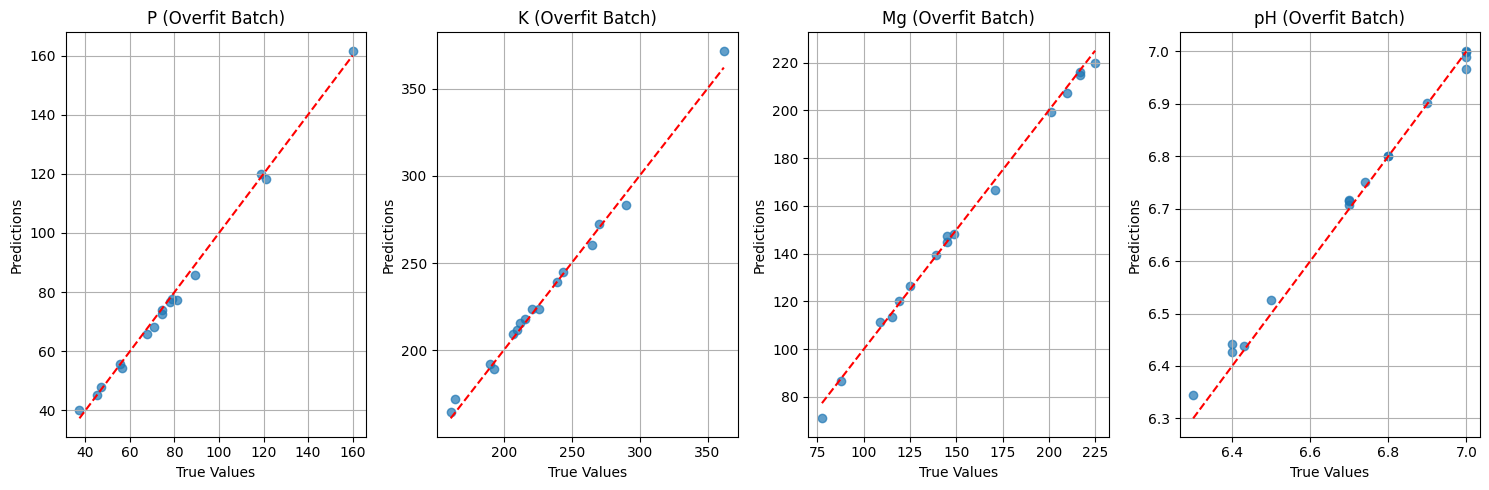

In [308]:

plt.figure(figsize=(15, 5))

metrics = ['P', 'K', 'Mg', 'pH']
for i, metric in enumerate(metrics):
    plt.subplot(1, 4, i + 1) # 1 row, 4 columns
    plt.scatter(unscaled_true_values[:, i], unscaled_predictions[:, i], alpha=0.7)
    plt.plot([min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             [min(unscaled_true_values[:, i]), max(unscaled_true_values[:, i])],
             'r--') # Red dashed line for ideal prediction
    plt.title(f'{metric} (Overfit Batch)')
    plt.xlabel('True Values')
    plt.ylabel('Predictions')
    plt.grid(True)

plt.tight_layout()
plt.show()


Learning loop

In [309]:

# ----- Model -----
model = HyperspectralRegressor(
    in_channels=3,   # PCA-reduced channels
    n_outputs=4,      # P, K, Mg, pH
    backbone_name="efficientnet_b2",
    pretrained=True
)

model = model.to(device);

# ----- Optimizer -----
optimizer = optim.AdamW([
    {"params": model.backbone.parameters(), "lr": 5e-5},
    {"params": model.regressor.parameters(), "lr": 2e-4},  # ↓ key fix
], weight_decay=1e-4)

# ----- Loss -----
criterion = nn.MSELoss()

# ----- Scheduler -----
scheduler = ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.3,
    patience=5,
    min_lr=1e-6
)

# ----- Hyperparameters -----
epochs = 120
patience = 20  # early stopping patience
warmup_epochs = 6 # Number of epochs for warm-up

# ----- Initialize wandb -----
# Initializing Weights & Biases for experiment tracking.
wandb.init(
    project="hyperview_challenge efficientnet_b2 (pretrained encoder!), warm up phase and gradient clipping added, 10M pixels rand pca",
    config={
        "learning_rate_backbone": 5e-5,
        "learning_rate_head": 2e-4, # Corrected to match optimizer
        "epochs": epochs,
        "batch_size": 16,
        "optimizer": "AdamW",
        "criterion": "MSELoss",
        "backbone": "efficientnet_b2",
        "pca_components": 3, # Consistent with the new n_components
        "scheduler": "ReduceLROnPlateau",
        "scheduler_factor": 0.3,
        "scheduler_patience": 5,
        "min_lr": 1e-6,
        "warmup_epochs": warmup_epochs # Added warm-up epochs to config
    }
)
# Log a note to wandb about this run's configuration
wandb.run.log({"note": "This run uses an efficientnet_b2 backbone with pre-trained weights (!), with a warm-up phase for the learning rate, and PCA applied to 10M pixels randomly sampled pixels from the training data. 3 PCA components used. Gradient clipping added."})


In [310]:
# ----- Training with early stopping -----
best_val_loss = float('inf')
counter = 0

# Store initial learning rates for warm-up
initial_lr_backbone = optimizer.param_groups[0]['lr']
initial_lr_head = optimizer.param_groups[1]['lr']

for epoch in range(epochs):
    model.train()
    running_loss = 0.0
    loop = tqdm(train_loader, desc=f"Epoch {epoch+1}/{epochs}", leave=False)

    # --- Warm-up logic ---
    if epoch < warmup_epochs:
        warmup_factor = (epoch + 1) / warmup_epochs
        for i, param_group in enumerate(optimizer.param_groups):
            if i == 0: # Backbone
                param_group['lr'] = initial_lr_backbone * warmup_factor
            else: # Regressor Head
                param_group['lr'] = initial_lr_head * warmup_factor

    for x, y in loop:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        outputs = model(x)
        loss = criterion(outputs, y)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        running_loss += loss.item()
        loop.set_postfix(loss=loss.item())

    train_loss = running_loss / len(train_loader)

    # ----- Validation -----
    model.eval()
    val_loss = 0.0
    with torch.no_grad():
        for X_val_batch, y_val_batch in val_loader:
            X_val_batch, y_val_batch = X_val_batch.to(device), y_val_batch.to(device)
            val_preds = model(X_val_batch)
            val_loss += criterion(val_preds, y_val_batch).item()
    val_loss /= len(val_loader)

    # Get current learning rates for logging
    current_lr_backbone = optimizer.param_groups[0]['lr']
    current_lr_head = optimizer.param_groups[1]['lr']

    print(f"Epoch {epoch+1}/{epochs} - Train Loss: {train_loss:.4f} - Val Loss: {val_loss:.4f} - backbone LR: {current_lr_backbone:.6f} - head LR: {current_lr_head:.6f}")

    # ----- Log to wandb -----
    wandb.log({"train_loss": train_loss, "val_loss": val_loss, "epoch": epoch, "learning_rate_backbone": current_lr_backbone, "learning_rate_head": current_lr_head})

    # ----- Scheduler step (only after warm-up) -----
    if epoch >= warmup_epochs - 1: # Apply scheduler after warm-up finishes
        scheduler.step(val_loss)

    # ----- Early stopping -----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        counter = 0
        torch.save(model.state_dict(), "best_hyperspectral_model.pth")
    else:
        counter += 1
        if counter >= patience:
            print(f"Early stopping triggered at epoch {epoch+1}")
            break

# ----- Load best model -----
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# ----- Finish wandb -----
wandb.finish()

Epoch 1/120 - Train Loss: 1.0115 - Val Loss: 0.9233 - backbone LR: 0.000008 - head LR: 0.000033


Epoch 2/120 - Train Loss: 0.9557 - Val Loss: 0.9194 - backbone LR: 0.000017 - head LR: 0.000067


Epoch 3/120 - Train Loss: 0.8955 - Val Loss: 0.9073 - backbone LR: 0.000025 - head LR: 0.000100


Epoch 4/120 - Train Loss: 0.8521 - Val Loss: 0.9003 - backbone LR: 0.000033 - head LR: 0.000133


Epoch 5/120 - Train Loss: 0.8085 - Val Loss: 0.9177 - backbone LR: 0.000042 - head LR: 0.000167


...

Epoch 21/120 - Train Loss: 0.3062 - Val Loss: 1.0251 - backbone LR: 0.000005 - head LR: 0.000018


Epoch 22/120 - Train Loss: 0.3277 - Val Loss: 1.0076 - backbone LR: 0.000005 - head LR: 0.000018


Epoch 23/120 - Train Loss: 0.2891 - Val Loss: 1.0237 - backbone LR: 0.000005 - head LR: 0.000018


Epoch 24/120 - Train Loss: 0.2965 - Val Loss: 0.9992 - backbone LR: 0.000005 - head LR: 0.000018
Early stopping triggered at epoch 24


epoch,▁▁▂▂▂▃▃▃▃▄▄▄▅▅▅▆▆▆▆▇▇▇██
learning_rate_backbone,▂▃▄▅▇███████▃▃▃▃▃▃▁▁▁▁▁▁
learning_rate_head,▂▃▄▅▇███████▃▃▃▃▃▃▁▁▁▁▁▁
train_loss,█▇▇▆▆▆▅▅▄▃▃▃▂▂▂▂▂▁▁▁▁▁▁▁
val_loss,▂▂▁▁▂▂▃▄▃▆▆▆▇▇█▆▆▇█▇▇▇▇▆
epoch,23
learning_rate_backbone,0.0
learning_rate_head,2e-05
note,This run uses an eff...
train_loss,0.29652
val_loss,0.99921


Evaluate results in comparision to the Baseline Regressor.

In [311]:
class BaselineRegressor:
    """
    Baseline regressor, which calculates the mean value of the target from the training
    data and returns it for each testing sample.
    """
    def __init__(self):
        self.mean = 0

    def fit(self, X_train: np.ndarray, y_train: np.ndarray):
        self.mean = np.mean(y_train, axis=0)
        self.classes_count = y_train.shape[1]
        return self

    def predict(self, X_test: np.ndarray):
        return np.full((len(X_test), self.classes_count), self.mean)


class SpectralCurveFiltering():
    """
    Create a histogram (a spectral curve) of a 3D cube, using the merge_function
    to aggregate all pixels within one band. The return array will have
    the shape of [CHANNELS_COUNT]
    """

    def __init__(self, merge_function = np.mean):
        self.merge_function = merge_function

    def __call__(self, sample: np.ndarray):
        return self.merge_function(sample, axis=(1, 2))

In [312]:
def evaluate_dl_model(model, test_loader, scaler_y, device):
    """Evaluates the deep learning model on the test dataset."""
    model.eval()
    test_predictions_scaled = []
    y_true_scaled = [] # To collect the true scaled labels from the DataLoader

    with torch.no_grad():
        for X_batch_test, y_batch_true_scaled in test_loader:
            X_batch_test = X_batch_test.to(device)
            preds_batch = model(X_batch_test)
            test_predictions_scaled.append(preds_batch.cpu().numpy())
            y_true_scaled.append(y_batch_true_scaled.cpu().numpy())

    y_test_scaled_pred = np.vstack(test_predictions_scaled)
    y_test_scaled_true = np.vstack(y_true_scaled)

    # Inverse transform predictions and true values
    y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)
    y_test_true_from_loader = scaler_y.inverse_transform(y_test_scaled_true)

    model_mse_targets = np.mean((y_test_true_from_loader - y_test_pred)**2, axis=0)
    return y_test_pred, y_test_true_from_loader, model_mse_targets

def evaluate_baseline_regressor(baseline_regressor, X_test_filtered, y_test_true):
    """Evaluates the baseline regressor on the test dataset."""
    baseline_preds_test = baseline_regressor.predict(X_test_filtered)
    baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)
    return baseline_preds_test, baseline_mse_targets

def calculate_and_print_results(model_mse_targets, baseline_mse_targets, y_test_true, y_test_pred, baseline_preds_test):
    """Calculates and prints the challenge score and per-target comparison, and plots results."""
    challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

    target_names = ["P", "K", "Mg", "pH"]
    print("Per-target comparison (on local test set from training data):")
    for i, name in enumerate(target_names):
        print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

    print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

    # Plotting
    plt.figure(figsize=(15, 5))
    for i, metric in enumerate(target_names):
        plt.subplot(1, 4, i + 1)
        plt.scatter(y_test_true[:, i], y_test_pred[:, i], alpha=0.7, label='DL Model Predictions')
        plt.scatter(y_test_true[:, i], baseline_preds_test[:, i], alpha=0.7, label='Baseline Predictions', marker='x')
        min_val = min(y_test_true[:, i].min(), y_test_pred[:, i].min(), baseline_preds_test[:, i].min())
        max_val = max(y_test_true[:, i].max(), y_test_pred[:, i].max(), baseline_preds_test[:, i].max())
        plt.plot([min_val, max_val], [min_val, max_val], 'r--', label='Ideal Prediction')
        plt.title(f'{metric} Predictions')
        plt.xlabel('True Values')
        plt.ylabel('Predictions')
        plt.grid(True)
        plt.legend()
    plt.tight_layout()
    plt.show()

In [313]:
# Get true y values from the local test dataset (inverse-scaled)
y_test_scaled_true = np.array([test_dataset[i][1].numpy() for i in range(len(test_dataset))])
y_test_true = scaler_y.inverse_transform(y_test_scaled_true)

In [314]:
# We need the original unscaled, non-PCA data for the baseline regressor
X_test_nonpca = [X_train[i] for i in test_indices]

# We need to apply SpectralCurveFiltering to the original X_test_nonpca for the baseline regressor
filtering = SpectralCurveFiltering()
X_test_filtered = np.array([filtering(cube.cpu().numpy()) for cube in X_test_nonpca])

# Train a new baseline regressor on the combined training and validation splits
# Combine train and validation indices
combined_train_val_indices = train_indices.tolist() + val_indices.tolist() # Convert to list for concatenation

# Get the original unscaled, non-PCA data for the baseline training
X_combined_train_val_nonpca = [X_train[i] for i in combined_train_val_indices]
y_combined_train_val_nonpca = y_train[combined_train_val_indices] # Use unscaled y_train for baseline training

X_combined_train_val_filtered = np.array([filtering(cube.cpu().numpy()) for cube in X_combined_train_val_nonpca])

In [315]:
baseline_reg_current = BaselineRegressor() # Initialize a new baseline regressor
baseline_reg_current = baseline_reg_current.fit(X_combined_train_val_filtered, y_combined_train_val_nonpca)

baseline_preds_test = baseline_reg_current.predict(X_test_filtered)

In [316]:
# Load the best model weights
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))
model.eval()

# Iterate through the local test loader to get predictions
test_predictions_scaled = []

# # Create a DataLoader for the local test dataset
# local_test_loader = DataLoader(test_dataset, batch_size=16, shuffle=False)

with torch.no_grad():
    for X_batch_test, _ in test_loader:
        X_batch_test = X_batch_test.to(next(model.parameters()).device)
        preds_batch = model(X_batch_test)
        test_predictions_scaled.append(preds_batch.cpu().numpy())

y_test_scaled_pred = np.vstack(test_predictions_scaled) # predicted in scaled units

# Convert to numpy and inverse scale to original units
y_test_pred = scaler_y.inverse_transform(y_test_scaled_pred)

In [317]:
# -----------------------------
# Compute MSE per target
# -----------------------------
model_mse_targets = np.mean((y_test_true - y_test_pred)**2, axis=0)
baseline_mse_targets = np.mean((y_test_true - baseline_preds_test)**2, axis=0)

# Compute normalized score (challenge metric)
challenge_score = np.mean(model_mse_targets / baseline_mse_targets)

# -----------------------------
# Print per-target comparison
# -----------------------------
target_names = ["P", "K", "Mg", "pH"]
print("Per-target comparison (on local test set from training data):")
for i, name in enumerate(target_names):
    print(f"{name}: Model MSE = {model_mse_targets[i]:.4f}, Baseline MSE = {baseline_mse_targets[i]:.4f}, Normalized = {model_mse_targets[i]/baseline_mse_targets[i]:.4f}")

print(f"\nChallenge normalized score (lower is better, on local test set): {challenge_score:.4f}")

Per-target comparison (on local test set from training data):
P: Model MSE = 844.2909, Baseline MSE = 833.2123, Normalized = 1.0133
K: Model MSE = 3987.7471, Baseline MSE = 4031.7278, Normalized = 0.9891
Mg: Model MSE = 1444.8723, Baseline MSE = 1499.2853, Normalized = 0.9637
pH: Model MSE = 0.0674, Baseline MSE = 0.0724, Normalized = 0.9315

Challenge normalized score (lower is better, on local test set): 0.9744


Per-target comparison (on local test set from training data):
P: Model MSE = 844.2909, Baseline MSE = 833.2123, Normalized = 1.0133
K: Model MSE = 3987.7471, Baseline MSE = 4031.7278, Normalized = 0.9891
Mg: Model MSE = 1444.8723, Baseline MSE = 1499.2853, Normalized = 0.9637
pH: Model MSE = 0.0674, Baseline MSE = 0.0724, Normalized = 0.9315

Challenge normalized score (lower is better, on local test set): 0.9744


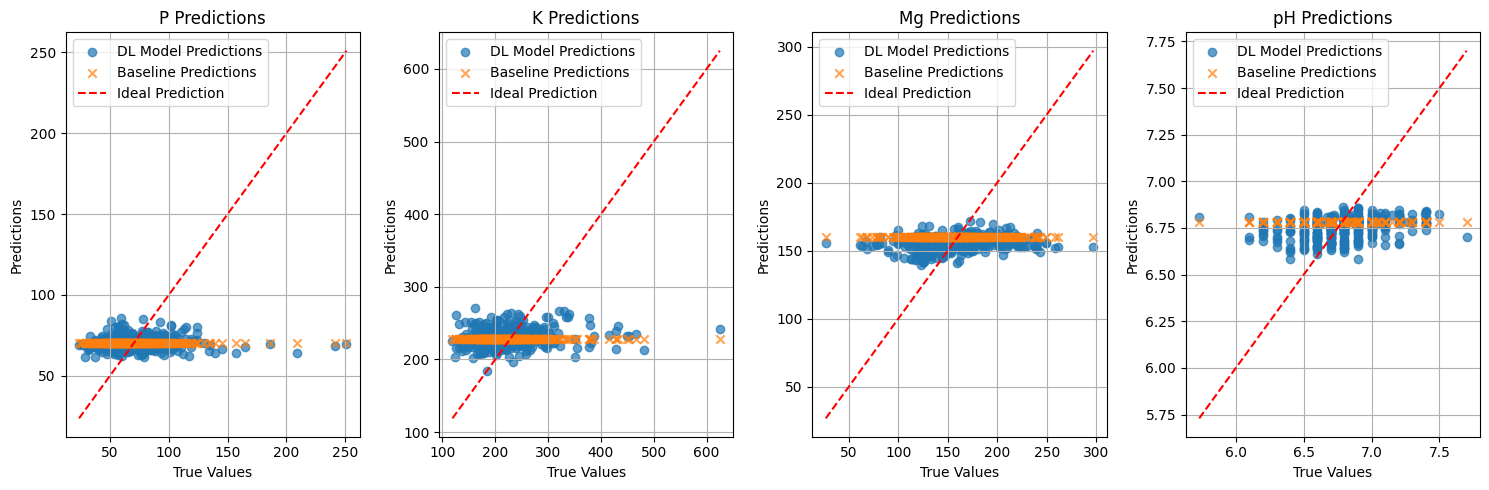

In [318]:
# Load the best model weights for the deep learning model
model.load_state_dict(torch.load("best_hyperspectral_model.pth"))

# Evaluate the deep learning model
dl_y_test_pred, dl_y_test_true, dl_model_mse_targets = evaluate_dl_model(model, test_loader, scaler_y, device)

# Evaluate the baseline regressor (using the globally available y_test_true from inverse scaling test_dataset labels)
baseline_y_test_pred, baseline_mse_targets = evaluate_baseline_regressor(baseline_reg_current, X_test_filtered, y_test_true)

# Calculate and print combined results, including plotting
calculate_and_print_results(dl_model_mse_targets, baseline_mse_targets, y_test_true, dl_y_test_pred, baseline_y_test_pred)

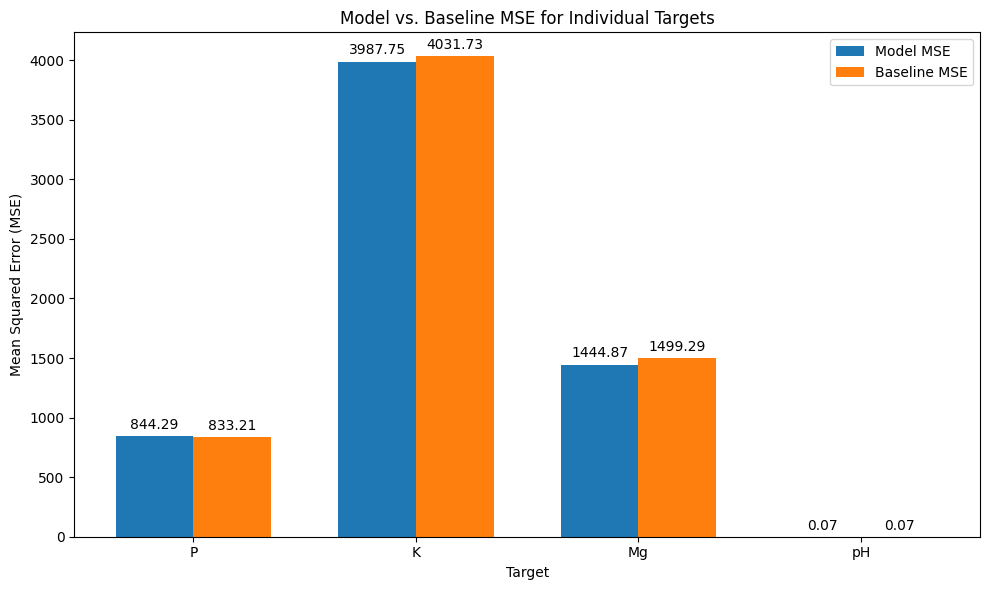

In [319]:
import matplotlib.pyplot as plt
import numpy as np

target_names = ["P", "K", "Mg", "pH"]

# Get the MSEs from the kernel state
# Assuming model_mse_targets and baseline_mse_targets are available from previous execution
model_mse_targets = np.array(model_mse_targets) # Ensure it's a numpy array for indexing
baseline_mse_targets = np.array(baseline_mse_targets) # Ensure it's a numpy array for indexing

x = np.arange(len(target_names))  # the label locations
width = 0.35  # the width of the bars

fig, ax = plt.subplots(figsize=(10, 6))
rects1 = ax.bar(x - width/2, model_mse_targets, width, label='Model MSE')
rects2 = ax.bar(x + width/2, baseline_mse_targets, width, label='Baseline MSE')

# Add some text for labels, title and custom x-axis tick labels, etc.
ax.set_xlabel('Target')
ax.set_ylabel('Mean Squared Error (MSE)')
ax.set_title('Model vs. Baseline MSE for Individual Targets')
ax.set_xticks(x)
ax.set_xticklabels(target_names)
ax.legend()

def autolabel(rects):
    """Attach a text label above each bar in *rects*, displaying its height."""
    for rect in rects:
        height = rect.get_height()
        ax.annotate(f'{height:.2f}',
                    xy=(rect.get_x() + rect.get_width() / 2, height),
                    xytext=(0, 3),  # 3 points vertical offset
                    textcoords="offset points",
                    ha='center', va='bottom')

autolabel(rects1)
autolabel(rects2)

fig.tight_layout()
plt.show()

Fetching history for run: futile-dominion-1 (ID: rdqcj7jx)


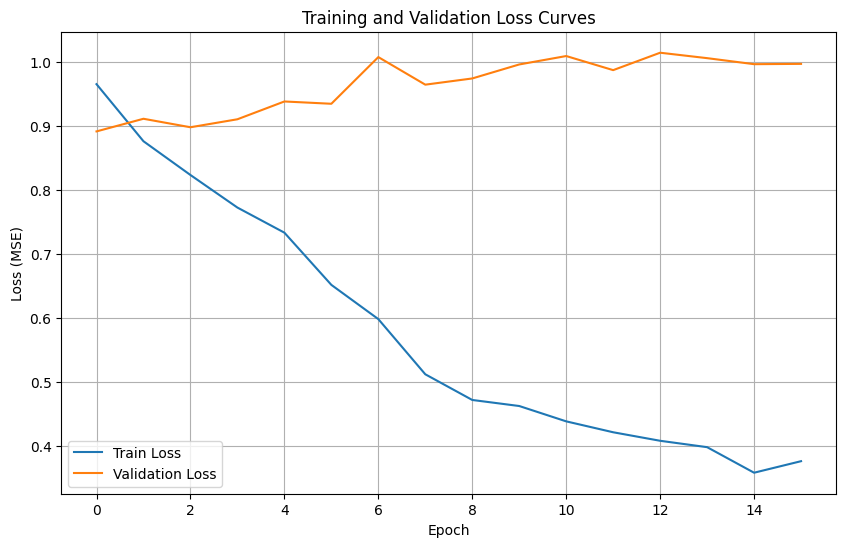

In [ ]:
import wandb
import matplotlib.pyplot as plt

# Assuming you are logged into wandb or using an anonymous account for the project.
# This will fetch the runs for the specified project.
# If you have multiple runs, you might need to specify the run ID or pick the latest one.

api = wandb.Api()
# Replace 'YOUR_ENTITY' with your Weights & Biases username or team name
# If you ran anonymously, the entity might be 'anonymous' or automatically inferred.
# We'll try to get the most recent run for the project.
runs = api.runs(path="hyperview_challenge efficientnet (pretrained encoder), rand pca", order="-created_at")

if runs:
    run = runs[0] # Get the latest run
    print(f"Fetching history for run: {run.name} (ID: {run.id})")
    history = run.history()

    plt.figure(figsize=(10, 6))
    plt.plot(history['epoch'], history['train_loss'], label='Train Loss')
    plt.plot(history['epoch'], history['val_loss'], label='Validation Loss')
    plt.title('Training and Validation Loss Curves')
    plt.xlabel('Epoch')
    plt.ylabel('Loss (MSE)')
    plt.legend()
    plt.grid(True)
    plt.show()
else:
    print("No runs found for the project 'hyperview_challenge efficientnet (pretrained encoder), rand pca'.")
    print("Please ensure you are logged into wandb or the project name is correct.")